# Assignment 5 Forecasting Methods

In [52]:
#imports
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from scipy.stats import t

In [ ]:
#data
df = pd.read_excel('/Users/fellabouznad/Desktop/Forecasting Methods/Assignment_1/DataAssignment1.xlsx')
y_1 = df['Var1'],
y_2 = df['Var2']
y_3 = df['Var3']
y_4 = df['Var4']
y_5 = df['Var5']
y_6 = df['Var6']
y_7 = df['Var7']
y_8 = df['Var8']
y_9 = df['Var9']

X = df[['Var1','Var2','Var3','Var4','Var5','Var6','Var7','Var8','Var9']]

In [17]:
#PC
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pc = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(pc, columns=[f'PC{i+1}' for i in range(9)])

exp_variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(9)],
    'Explained Variance Ratio': pca.explained_variance_ratio_
})

print(pc_df)
print(exp_variance)


         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0   2.708356 -0.599182 -0.218711  1.543416  0.348726 -0.196731 -0.884639   
1   2.505831 -0.387944 -0.248541  1.173982  0.179684 -0.269990 -1.382728   
2   2.418897 -0.716209  0.606515  0.769229  0.105032 -0.497498 -0.302554   
3   2.385228 -0.718287  0.678633  0.653802  0.783525 -0.588134  0.372139   
4   1.655979 -0.992518  0.523791  0.668613 -0.311023 -0.267177 -0.001672   
5   2.215325 -0.187789  0.684745 -0.067502  0.219601 -0.808765 -0.225129   
6   2.238899 -0.852942  0.958645 -0.077854  0.090255 -0.210272  0.192259   
7   3.681944 -1.233679  0.614252  0.058602 -0.263420  0.823594  0.541296   
8   2.844651 -0.336672  1.444789 -0.714958 -0.102055  0.568674  0.595961   
9   2.657563 -1.074661  0.641927 -0.214663 -0.179419  0.585295  0.635230   
10  2.297722 -1.793318 -0.679263  0.024082 -0.839903 -0.244113  0.457792   
11  2.175401 -1.080350 -0.096713 -0.848266 -0.265170  0.077644 -0.321431   
12  1.438732

In [18]:
pc_df_rounded = pc_df.round(3)
exp_variance_rounded = exp_variance.round(3)

print(pc_df_rounded)
print(exp_variance_rounded)

      PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9
0   2.708 -0.599 -0.219  1.543  0.349 -0.197 -0.885  0.045 -0.068
1   2.506 -0.388 -0.249  1.174  0.180 -0.270 -1.383  0.082 -0.006
2   2.419 -0.716  0.607  0.769  0.105 -0.497 -0.303 -0.094  0.037
3   2.385 -0.718  0.679  0.654  0.784 -0.588  0.372 -0.449 -0.226
4   1.656 -0.993  0.524  0.669 -0.311 -0.267 -0.002 -0.034  0.277
5   2.215 -0.188  0.685 -0.068  0.220 -0.809 -0.225 -0.179  0.158
6   2.239 -0.853  0.959 -0.078  0.090 -0.210  0.192  0.210  0.602
7   3.682 -1.234  0.614  0.059 -0.263  0.824  0.541 -0.177  0.052
8   2.845 -0.337  1.445 -0.715 -0.102  0.569  0.596  0.621 -0.054
9   2.658 -1.075  0.642 -0.215 -0.179  0.585  0.635  0.332 -0.200
10  2.298 -1.793 -0.679  0.024 -0.840 -0.244  0.458  0.275 -0.340
11  2.175 -1.080 -0.097 -0.848 -0.265  0.078 -0.321  0.426 -0.095
12  1.439 -0.458  0.215 -0.828 -0.919 -1.005 -0.075  0.177 -0.026
13  2.386  0.475  0.785 -0.459 -1.002  0.469 -0.413 -0.103 -0.145
14  1.779 

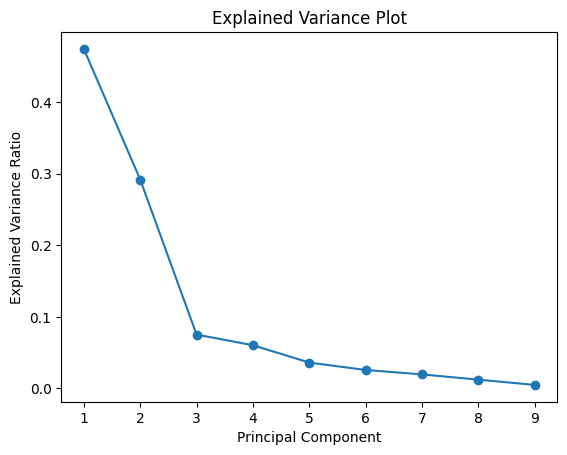

In [21]:
#PC plot
plt.figure()
plt.plot(range(1, 10), pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Plot')
plt.show()

In [22]:
#stock and watson constants
T = 30
k = 3
h = 1

In [32]:
#construct F
F = pc_df.iloc[:,:k]
m_values = [1,2,3,4,5,6,7,8,9,10]
p_values = [1,2,3,4,5,6,7,8,9,10]

In [25]:
#autoregressive distributed lag model
def adl_dataprep(y,F,m,p,h):
    data = pd.concat([y,F], axis=1)
    data.columns = ['y'] + [f'PC{i+1}' for i in range(k)]
    X_list = []
    y_list = []
    max_lag = max(m,p)
    
    for t in range(max_lag, len(data)-h):
        row = []
        for i in range(m):
            row.extend(data.iloc[t-i,1:].values) #lags F
        for j in range(p):
            row.append(data.iloc[t-j,0]) #lags y
        
        X_list.append(row)
        y_list.append(data.iloc[t+h,0])

    X_list = np.array(X_list)
    y_list = np.array(y_list)
    return X_list, y_list, max_lag

In [ ]:
#select m and p
best_lags = {}
mae_table = {}
mape_table = {}
mse_table = {}
rmse_table = {}
for col in X.columns:
    y = X[col]
    best_combo = None
    best_mae = np.inf
    best_mape = np.inf
    best_mse = np.inf
    best_rmse = np.inf

    for m in m_values:
        for p in p_values:
            X_adl, y_adl, max_lag = adl_dataprep(y,F,m,p,h)
            X_train = X_adl[:T-max_lag]
            y_train = y_adl[:T-max_lag]

            X_test = X_adl[T-max_lag:T-max_lag+10]
            y_test = y_adl[T-max_lag:T-max_lag+10]

            model = LinearRegression() 
            model.fit(X_train, y_train)
            y_h = model.predict(X_test)

            e = y_test - y_h
            mae = mean_absolute_error(y_test,y_h)
            mape = np.mean(np.abs(e/y_test))*100
            mse = mean_squared_error(y_test,y_h)
            rmse = np.sqrt(mse) 

            #mz testing

            #dm testing

            if rmse < best_rmse:
                  best_mae = mae
                  best_mape = mape
                  best_mse = mse
                  best_rmse = rmse
                  best_combo = (m,p)

    best_lags[col] = best_combo
    mae_table[col] = best_mae
    mape_table[col] = best_mape
    mse_table[col] = best_mse
    rmse_table[col] = best_rmse

results_df = pd.DataFrame({'(m,p)': best_lags, 'MAE': mae_table, 'MAPE': mape_table, 'MSE': mse_table, 'RMSE': rmse_table})

In [43]:
print(results_df)

        (m,p)       MAE      MAPE       MSE      RMSE
Var1   (1, 5)  2.409287  5.782813  7.572310  2.751783
Var2  (10, 5)  1.705854  3.084847  3.934775  1.983627
Var3   (1, 1)  1.523531  3.872323  3.561509  1.887196
Var4   (1, 1)  1.155288  3.657711  2.518080  1.586846
Var5   (1, 7)  1.764186  7.183668  4.607681  2.146551
Var6   (1, 1)  2.064463  4.375867  6.010357  2.451603
Var7   (3, 2)  1.634472  4.165201  3.548886  1.883849
Var8   (3, 2)  1.317815  4.430896  2.387051  1.545008
Var9   (5, 2)  2.638460  9.674477  9.411185  3.067765


In [44]:
#dm test (as in our assignment 2)
def dm_test(e1, e2):
    d = e1**2 - e2**2
    d = d[~np.isnan(d)]

    mean_d = np.mean(d)
    se = np.std(d, ddof=1) / np.sqrt(len(d))

    stat = mean_d / se
    p = 2 * (1 - t.cdf(abs(stat), df=len(d)-1))
    return stat, p


In [45]:
#zm test (as in our assignment 2)
def mz_test(y, yhat):

    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    X = sm.add_constant(yhat)
    model = sm.OLS(y, X).fit()

    ftest = model.f_test("const = 0, x1 = 1")

    return model, float(ftest.fvalue), float(ftest.pvalue)

In [46]:
#local level benchmark (as in assignment 2)
def local_level_errors(y, T, h):
    y = pd.Series(y).reset_index(drop=True)
    errors = []
    for t in range(T, T+10):
        y_hat = y[t-1]     
        y_real = y[t]       
        errors.append(y_real - y_hat)

    return np.array(errors)

In [53]:
#testing
adl_forecasts = {}
adl_errors = {}
mz_results = {}
dm_results = {}

for col in X.columns:
    y = X[col]
    m, p = best_lags[col]

    X_adl, y_adl, max_lag = adl_dataprep(y, F, m, p, h)
    X_train = X_adl[:T-max_lag]
    y_train = y_adl[:T-max_lag]
    X_test = X_adl[T-max_lag:T-max_lag+10]
    y_test = y_adl[T-max_lag:T-max_lag+10]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_hat = model.predict(X_test)
    e_adl = y_test - y_hat

    adl_forecasts[col] = y_hat
    adl_errors[col] = e_adl

    mz_model, mz_fstat, mz_pval = mz_test(y_test, y_hat)
    mz_results[col] = (mz_fstat, mz_pval)

    e_ll = local_level_errors(y, T, h)

    min_len = min(len(e_adl), len(e_ll))
    e_adl_aligned = e_adl[:min_len]
    e_ll_aligned = e_ll[:min_len]

    dm_stat, dm_pval = dm_test(e_adl_aligned, e_ll_aligned)
    dm_results[col] = (dm_stat, dm_pval)

results_df['MZ_F'] = results_df.index.map(lambda x: mz_results[x][0])
results_df['MZ_p'] = results_df.index.map(lambda x: mz_results[x][1])

results_df['DM_t'] = results_df.index.map(lambda x: dm_results[x][0])
results_df['DM_p'] = results_df.index.map(lambda x: dm_results[x][1])

results_df = results_df.round(3)

print(results_df)

        (m,p)    MAE   MAPE    MSE   RMSE    MZ_F   MZ_p   DM_t   DM_p
Var1   (1, 5)  2.409  5.783  7.572  2.752   4.480  0.050  2.084  0.067
Var2  (10, 5)  1.706  3.085  3.935  1.984   2.470  0.146 -0.445  0.667
Var3   (1, 1)  1.524  3.872  3.562  1.887   1.100  0.378 -0.788  0.451
Var4   (1, 1)  1.155  3.658  2.518  1.587   3.460  0.083 -0.351  0.733
Var5   (1, 7)  1.764  7.184  4.608  2.147   6.108  0.025 -0.238  0.817
Var6   (1, 1)  2.064  4.376  6.010  2.452  10.179  0.006  1.699  0.124
Var7   (3, 2)  1.634  4.165  3.549  1.884   1.146  0.365 -0.398  0.700
Var8   (3, 2)  1.318  4.431  2.387  1.545   2.495  0.144 -0.263  0.799
Var9   (5, 2)  2.638  9.674  9.411  3.068   3.349  0.088  0.857  0.414
